In [19]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
# Load the heart disease dataset
data = pd.read_csv("heart.csv")
print(data.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


In [21]:
# Check dataset information
print("Shape:", data.shape)
data.info()


Shape: (297, 14)
<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [22]:
# Check missing values
print(data.isnull().sum())


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [23]:
# Check heart disease distribution
print(data["condition"].value_counts())


condition
0    160
1    137
Name: count, dtype: int64


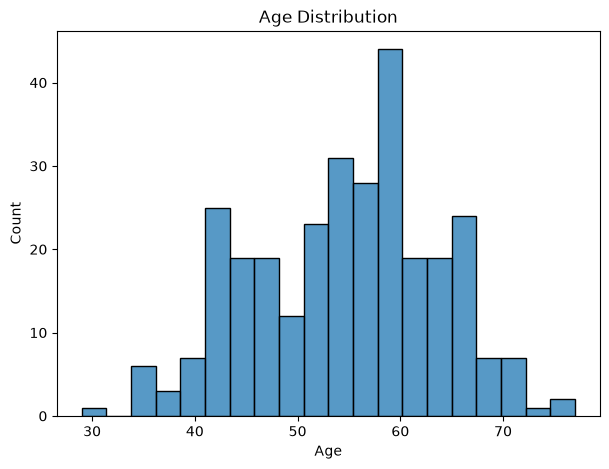

In [24]:
# Plot age distribution
plt.figure(figsize=(7,5))
sns.histplot(data["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


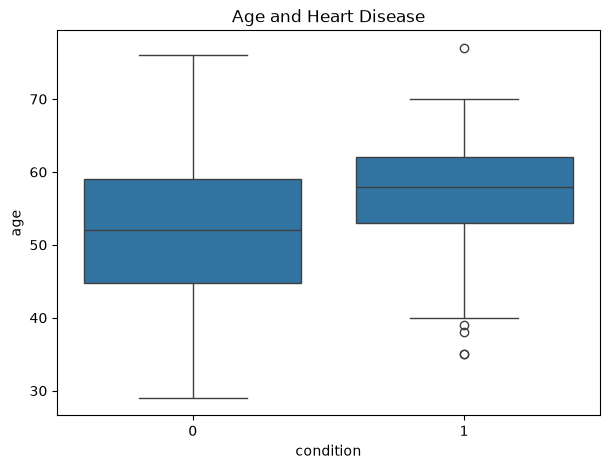

In [25]:
# Compare age with heart disease
plt.figure(figsize=(7,5))
sns.boxplot(x="condition", y="age", data=data)
plt.title("Age and Heart Disease")
plt.show()


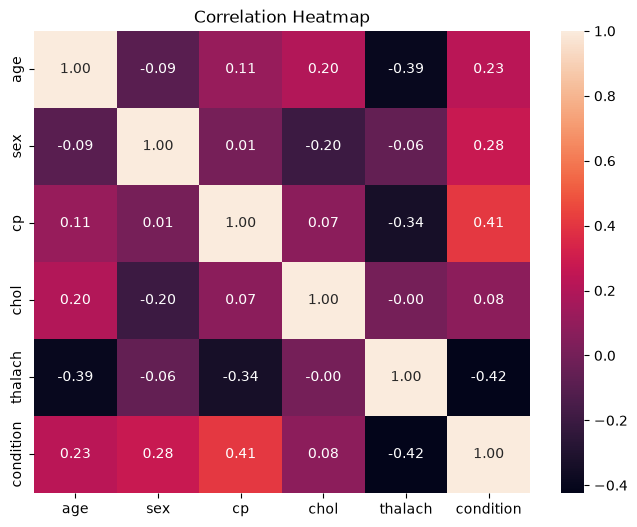

In [26]:
# Show correlation between selected variables
plt.figure(figsize=(8,6))
sns.heatmap(data[["age", "sex", "cp", "chol", "thalach", "condition"]].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [27]:
# Select input and output variables
features = ["age", "sex", "cp", "chol", "thalach"]
X = data[features]
y = data["condition"]
print("Features:", features)
print("Input shape:", X.shape)
print("Output shape:", y.shape)


Features: ['age', 'sex', 'cp', 'chol', 'thalach']
Input shape: (297, 5)
Output shape: (297,)


In [28]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (237, 5)
Testing data: (60, 5)


In [29]:
# Train the Random Forest ensemble model
from sklearn.ensemble import RandomForestClassifier

ensemble_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

ensemble_model.fit(X_train, y_train)
ensemble_pred = ensemble_model.predict(X_test)

print("Random Forest ensemble trained successfully")


Random Forest ensemble trained successfully


In [30]:
# Check model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, ensemble_pred)
print("Random Forest Ensemble Accuracy:", accuracy)


Random Forest Ensemble Accuracy: 0.7666666666666667


In [31]:
# Check classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, ensemble_pred))


              precision    recall  f1-score   support

           0       0.80      0.75      0.77        32
           1       0.73      0.79      0.76        28

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



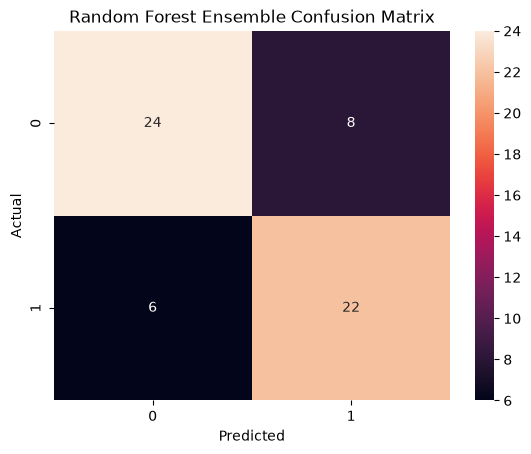

In [32]:
# Display confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ensemble_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [33]:
# Save the final model
import pickle

with open("heart_disease_ensemble.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("Model saved successfully")


Model saved successfully
